# Aula 06

## K-Nearest Neighbors (KNN): A intuição geométrica

Até agora, nossos modelos tentaram encontrar uma equação matemática para separar os dados. O **KNN** (**K-Vizinhos Mais Próximos**) faz algo completamente diferente. Ele não aprende uma equação. Ele simplesmente memoriza os dados.

A regra do KNN é o famoso ditado: *'Diga-me com quem andas e te direi quem és'*. Imagine que você quer classificar um ponto novo. O KNN calcula a distância geométrica desse ponto para todos os outros pontos do dataset (geralmente usando a distância Euclidiana, aquela mesma do Teorema de Pitágoras: $d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$).

Se você definir $K=3$, o algoritmo olha para os 3 pontos mais próximos. Se dois forem vermelhos e um for azul, por votação da maioria, o ponto novo será classificado como vermelho.

Com um GIF fica melhor de entender:

![image](https://user-images.githubusercontent.com/75358720/161425446-e086dc39-4683-4590-b6cb-9a96466bd589.gif)

Parece perfeito, não é? Mas o KNN sofre de um problema grave chamado **Maldição da Dimensionalidade**.

Quando você tem poucas colunas (ex: Idade e Salário, 2D), a distância funciona bem. Mas se você tiver 500 colunas (500 dimensões), o espaço fica tão vasto e vazio que a distância entre os pontos começa a perder o sentido matemático. Tudo fica *longe* de tudo. Portanto, o KNN é ótimo para poucas colunas, mas terrível para tabelas muito largas.

## Support Vector Machines (SVM) e as margens

O **SVM** (**Máquinas de Vetores de Suporte**) é um dos algoritmos mais bonitos do Machine Learning.

Imagine que você tem pontos azuis e vermelhos em uma folha de papel e precisa desenhar uma linha reta para separá-los. Você pode desenhar infinitas linhas. Qual é a melhor?

O SVM diz que a melhor linha (que em múltiplas dimensões chamamos de **Hiperplano**) é aquela que passa bem no meio das duas classes, mantendo a maior distância possível para os pontos mais próximos de cada classe. Essa distância de segurança é chamada de **Margem**. Os pontos que ficam bem na beira dessa margem são os 'Vetores de Suporte': eles são os únicos pontos que realmente importam para desenhar a linha.

Com um GIF fica mais fácil de entender:

![image](https://miro.medium.com/v2/resize:fit:828/format:webp/0*jZYiPNzEteuQbKme.gif)

E se os dados não puderem ser separados por uma linha reta? Imagine pontos vermelhos no centro de um alvo, cercados por pontos azuis. Nenhuma reta consegue cruzar a tela e separar isso perfeitamente.

Aqui entra a magia do SVM: o **Kernel Trick**.
O SVM projeta matematicamente esses dados em uma dimensão maior. Ele pega os dados do papel (2D) e os *joga para o alto* (3D), baseando-se em alguma característica. No ar, em 3D, ele consegue passar uma folha de papel plana (um hiperplano) separando os vermelhos (em cima) dos azuis (embaixo). Quando a sombra dessa folha volta para o 2D, ela tem o formato de um círculo! O Kernel mais famoso para isso é o RBF (Radial Basis Function).

Mais fácil de compreender com uma foto:

![image](https://www.eric-kim.net/eric-kim-net/posts/1/imgs/data_2d_to_3d_hyperplane.png)

## Criar o dataset

In [1]:
# --- Importar as bibliotecas --- #
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [4]:
# -- Criaro o dataset --- #
# --- noise adiciona ruído e dificulta a vida do algoritmo --- #
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

# --- Dividir em treino e teste --- #
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    train_size=0.3,
    random_state=42
)

# --- Como o KNN e SVM dependem de distâncias, é obrigatório escalonar --- #
escalonador = StandardScaler()
X_treino = escalonador.fit_transform(X_treino)
X_teste = escalonador.transform(X_teste)

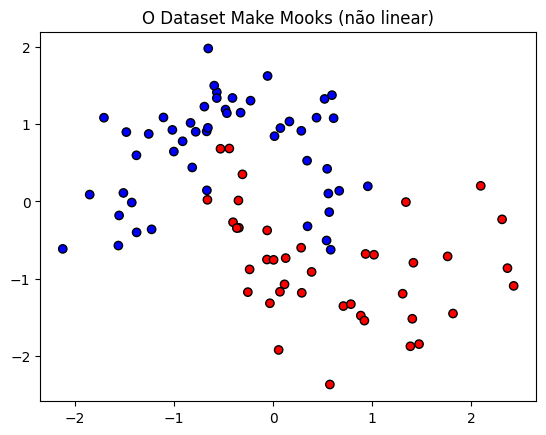

In [6]:
# --- Visulozar alguns dados --- #
plt.scatter(X_treino[:, 0], X_treino[:, 1], c=y_treino, cmap='bwr', edgecolor='k')
plt.title('O Dataset Make Mooks (não linear)')
plt.show()

## Treinar o KNN e SVM

In [7]:
# --- Importar os modelos --- #
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

In [10]:
# --- KNN --- #
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_treino, y_treino)
knn_predicao = knn.predict(X_teste)

# --- SVM linear --- #
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_treino, y_treino)
svm_linear_predicao = svm_linear.predict(X_teste)

# --- SVM RBF --- #
svm_rbf = SVC(kernel='rbf', C=1)  # C é a rigidez da margem
svm_rbf.fit(X_treino, y_treino)
svm_rbf_predicao = svm_rbf.predict(X_teste)

# --- Mostrar a acurácia de cada modelo --- #
print(f'''KNN (K=5): {accuracy_score(y_teste, knn_predicao):.2%}
SVM Linear: {accuracy_score(y_teste, svm_linear_predicao):.2%}
SVM RBF: {accuracy_score(y_teste, svm_rbf_predicao):.2%}''')

KNN (K=5): 94.29%
SVM Linear: 87.14%
SVM RBF: 93.33%


Perceba pelas métricas impressas que o SVM Linear tem um desempenho pior. Ele tentou traçar uma reta no meio das luas. Já o KNN e o SVM com Kernel RBF entenderam a curva geométrica dos dados e atingiram acurácias melhores.

## Vantagens e desvantagens computacionais

Para encerrar, qual dos dois devemos escolher no mundo real? Vamos analisar o custo computacional.

**K-Nearest Neighbors (KNN)**:
- **O Treino ($O(1)$):** O treino é instantâneo. Ele literalmente não faz nenhum cálculo no `.fit()`, ele só salva a tabela na memória. Ele é um algoritmo preguiçoso (*Lazy Learner*).

- **A Previsão ($O(N)$):** A previsão é extremamente lenta. Se você tiver 1 milhão de clientes e quiser prever 1 novo, ele terá que calcular a distância contra 1 milhão de registros em tempo real.

- **Uso ideal:** Datasets muito pequenos com poucas colunas.

**Support Vector Machines (SVM):**
- **O Treino ($O(N^2)$ a $O(N^3)$):** O treino é pesado e matemático. Se você tiver um dataset gigante (ex: mais de 100 mil linhas), treinar um SVM com Kernel RBF pode demorar horas ou dias.

- **A Previsão:** É rapidíssima. Uma vez que ele encontrou os 'Vetores de Suporte', ele ignora todo o resto do dataset. Ele só calcula a distância para esses poucos pontos vitais.

- **Uso ideal:** Datasets complexos, não muito longos (em quantidade de linhas), mas que podem ser muito largos (muitas colunas). O SVM não sofre da maldição da dimensionalidade tão forte quanto o KNN.